# Análisis de Sentimientos — Reseñas de Celulares en Amazon

**Objetivo:** Analizar el sentimiento de reseñas de celulares en Amazon utilizando VADER, enriquecido con vocabulario del dominio de telefonía. Comparar con calificaciones reales para evaluar la efectividad del método.

## Configuración Inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, cohen_kappa_score
)

# Descargar recursos de NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Librerías cargadas correctamente.')

---
## Fase 1 — Exploración y Preprocesamiento

### 1.1 Carga y Exploración Inicial

In [6]:
# Cargar dataset
df = pd.read_csv('Amazon-Reviews-Essential.csv')
print(f'Total de reseñas: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
print(f'\nPrimeras filas:')
df.head()

Total de reseñas: 413,802
Columnas: ['Rating', 'Reviews']

Primeras filas:


,Rating,Reviews
0,5.0,I feel so LUCKY to have found this used (phone...
1,4.0,"nice phone, nice up grade from my pantach revu..."
2,5.0,Very pleased
3,4.0,It works good but it goes slow sometimes but i...
4,4.0,Great phone to replace my lost phone. The only...


In [7]:
# Estadísticas descriptivas
print('=== Estadísticas del Dataset ===')
print(f'Total de reseñas: {len(df):,}')
print(f'\nDistribución de Ratings:')
print(df['Rating'].value_counts().sort_index())
print(f'\nValores nulos:')
print(df.isnull().sum())
print(f'\nReseñas vacías: {(df["Reviews"] == "").sum()}')
print(f'Longitud promedio de texto: {df["Reviews"].str.len().mean():.0f} caracteres')

=== Estadísticas del Dataset ===
Total de reseñas: 413,802

Distribución de Ratings:
Rating
1.0     72343
2.0     24728
3.0     31760
4.0     61389
5.0    223566
Name: count, dtype: int64

Valores nulos:
Rating     16
Reviews    86
dtype: int64

Reseñas vacías: 0
Longitud promedio de texto: 217 caracteres


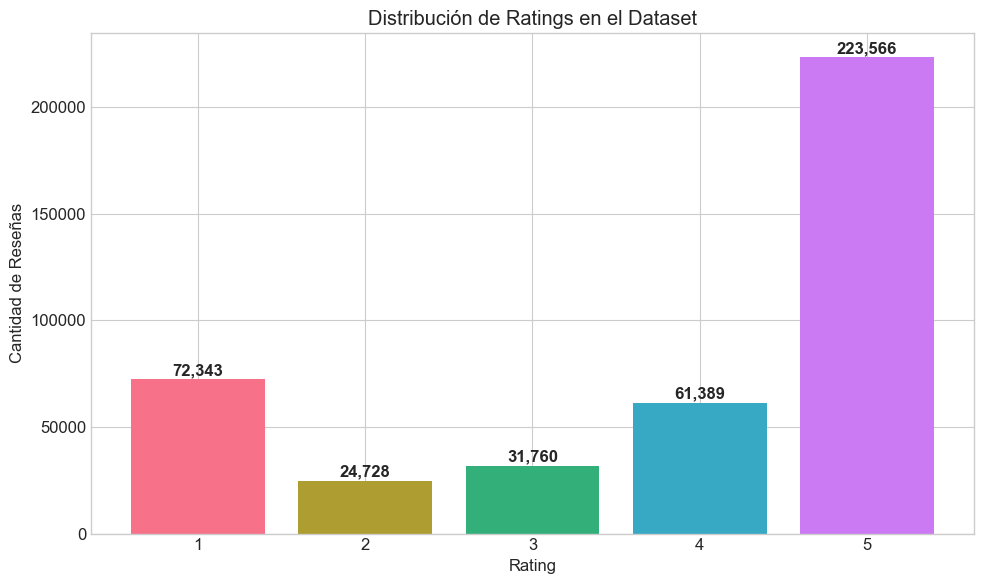

Gráfica guardada: 01_distribucion_ratings.png


In [8]:
# Histograma de distribución de ratings
fig, ax = plt.subplots(figsize=(10, 6))
rating_counts = df['Rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values, color=sns.color_palette('husl', 5))
ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad de Reseñas')
ax.set_title('Distribución de Ratings en el Dataset')
ax.set_xticks([1, 2, 3, 4, 5])

for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribucion_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 01_distribucion_ratings.png')

### 1.2 Limpieza del Texto

In [9]:
# Crear muestra estratificada para desarrollo rápido
SAMPLE_SIZE = 50000
if len(df) > SAMPLE_SIZE:
    df_sample = df.groupby('Rating', group_keys=False).apply(
        lambda x: x.sample(min(len(x), SAMPLE_SIZE // 5), random_state=42),
        include_groups=False
    ).reset_index(drop=True)
    # Restaurar columna Rating desde el índice original
    df_sample = df.loc[df_sample.index].copy()
    print(f'Muestra estratificada creada: {len(df_sample):,} reseñas')
else:
    df_sample = df.copy()
    print(f'Usando dataset completo: {len(df_sample):,} reseñas')

print(f'\nDistribución en muestra:')
print(df_sample['Rating'].value_counts().sort_index())

Muestra estratificada creada: 50,000 reseñas

Distribución en muestra:


KeyError: 'Rating'

In [10]:
def limpiar_texto(texto):
    """Limpia el texto de una reseña."""
    if pd.isna(texto):
        return ''
    
    # Convertir a string y minúsculas
    texto = str(texto).lower()
    
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)
    
    # Eliminar correos electrónicos
    texto = re.sub(r'\S+@\S+\.\S+', '', texto)
    
    # Eliminar caracteres especiales y números aislados
    # Conservar números que forman parte de modelos (ej: Galaxy S2)
    texto = re.sub(r'(?<![a-zA-Z])\d+(?![a-zA-Z])', '', texto)
    
    # Eliminar signos de puntuación
    texto = re.sub(r'[{}]'.format(re.escape(string.punctuation)), ' ', texto)
    
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# Aplicar limpieza
df_sample['Reviews_Limpio'] = df_sample['Reviews'].apply(limpiar_texto)

# Mostrar ejemplos
print('=== Ejemplos de Limpieza ===')
for i in range(3):
    print(f'\nOriginal: {df_sample.iloc[i]["Reviews"][:100]}...')
    print(f'Limpio: {df_sample.iloc[i]["Reviews_Limpio"][:100]}...')

=== Ejemplos de Limpieza ===

Original: The phone is okay, but then again its cheap. The only reason I'm giving it a single star is because ...
Limpio: the phone is okay but then again its cheap the only reason i m giving it a single star is because th...

Original: Battery is pathetic!!!...
Limpio: battery is pathetic...

Original: This phone has real good features, but doesn't work properly. Restarts by itself when ever it feels ...
Limpio: this phone has real good features but doesn t work properly restarts by itself when ever it feels li...


In [11]:
# Eliminar stopwords y lematizar
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def procesar_texto(texto):
    """Elimina stopwords y aplica lematización."""
    if not texto:
        return ''
    
    tokens = word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_sample['Reviews_Procesado'] = df_sample['Reviews_Limpio'].apply(procesar_texto)

print('Ejemplo de procesamiento:')
print(f'Limpio: {df_sample.iloc[0]["Reviews_Limpio"][:100]}...')
print(f'Procesado: {df_sample.iloc[0]["Reviews_Procesado"][:100]}...')

Ejemplo de procesamiento:
Limpio: the phone is okay but then again its cheap the only reason i m giving it a single star is because th...
Procesado: phone okay cheap reason giving single star screen came wavy noticeable white colored screen texting ...


### 1.3 Definición de Etiquetas Ground Truth

In [12]:
def rating_a_sentimiento(rating):
    """Convierte rating numérico a categoría de sentimiento."""
    if rating <= 2:
        return 'Negativo'
    elif rating == 3:
        return 'Neutro'
    else:
        return 'Positivo'

df_sample['Sentimiento_Real'] = df_sample['Rating'].apply(rating_a_sentimiento)

print('Distribución de sentimientos (ground truth):')
print(df_sample['Sentimiento_Real'].value_counts())
print(f'\nPorcentajes:')
print(df_sample['Sentimiento_Real'].value_counts(normalize=True).round(4) * 100)

KeyError: 'Rating'

---
## Fase 2 — Análisis de Sentimiento con VADER

### 2.1 Análisis con VADER Base

In [ ]:
# Análisis con VADER base (sin enriquecimiento)
sia_base = SentimentIntensityAnalyzer()

def analizar_sentimiento(texto, analyzer):
    """Analiza sentimiento usando VADER."""
    if not texto:
        return {'compound': 0, 'pos': 0, 'neg': 0, 'neu': 0}
    return analyzer.polarity_scores(texto)

# Aplicar análisis base
df_sample['Scores_Base'] = df_sample['Reviews_Limpio'].apply(
    lambda x: analizar_sentimiento(x, sia_base)
)
df_sample['Compound_Base'] = df_sample['Scores_Base'].apply(lambda x: x['compound'])

print('Estadísticas del compound score (VADER base):')
print(df_sample['Compound_Base'].describe())

### 2.2 Enriquecimiento del Léxico con Vocabulario del Dominio

In [ ]:
# Diccionario de dominio de telefonía
DOMAIN_LEXICON = {
    'laggy': -2.5, 'lag': -2.0, 'overheating': -2.5, 'overheat': -2.0,
    'bloatware': -2.0, 'bricked': -3.5, 'unresponsive': -2.5, 'cracked': -2.5,
    'refurbished': -0.5, 'glitchy': -2.0, 'dead pixel': -2.5, 'battery drain': -2.5,
    'fast charging': 2.0, 'snappy': 2.0, 'crisp': 1.5, 'flagship': 1.5,
    'waterproof': 1.5, 'upgrade': 1.5, 'downgrade': -2.0, 'scratched': -2.0,
    'durable': 1.5, 'flimsy': -2.0, 'overpriced': -2.0, 'bargain': 2.0,
    'scam': -3.5, 'knockoff': -2.5, 'defective': -3.0, 'freezing': -2.0,
    'smooth': 1.5, 'responsive': 1.5
}

print(f'Términos en el léxico de dominio: {len(DOMAIN_LEXICON)}')
print(f'\nTérminos negativos: {sum(1 for v in DOMAIN_LEXICON.values() if v < 0)}')
print(f'Términos positivos: {sum(1 for v in DOMAIN_LEXICON.values() if v > 0)}')

In [ ]:
# Crear VADER con léxico enriquecido
sia_enriched = SentimentIntensityAnalyzer()
sia_enriched.lexicon.update(DOMAIN_LEXICON)

print('Léxico de dominio agregado a VADER.')
print(f'Tamaño del léxico: {len(sia_enriched.lexicon)} palabras')

In [ ]:
# Aplicar análisis con léxico enriquecido
df_sample['Scores_Enriched'] = df_sample['Reviews_Limpio'].apply(
    lambda x: analizar_sentimiento(x, sia_enriched)
)
df_sample['Compound_Enriched'] = df_sample['Scores_Enriched'].apply(lambda x: x['compound'])

print('Estadísticas del compound score (VADER enriquecido):')
print(df_sample['Compound_Enriched'].describe())

### 2.3 Clasificación de Sentimientos

In [ ]:
def clasificar_sentimiento(compound):
    """Clasifica sentimiento según compound score."""
    if compound >= 0.05:
        return 'Positivo'
    elif compound <= -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

# Clasificar con ambos modelos
df_sample['Sentimiento_Base'] = df_sample['Compound_Base'].apply(clasificar_sentimiento)
df_sample['Sentimiento_Enriched'] = df_sample['Compound_Enriched'].apply(clasificar_sentimiento)

print('=== Distribución de Predicciones ===')
print(f'\nVADER Base:')
print(df_sample['Sentimiento_Base'].value_counts())
print(f'\nVADER Enriquecido:')
print(df_sample['Sentimiento_Enriched'].value_counts())

---
## Fase 3 — Evaluación del Modelo

### 3.1 Métricas de Evaluación

In [ ]:
def evaluar_modelo(y_true, y_pred, nombre):
    """Evalúa un modelo y retorna las métricas."""
    print(f'\n=== Evaluación: {nombre} ===')
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    
    # Classification Report
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred))
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f'Cohen\'s Kappa: {kappa:.4f}')
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=['Negativo', 'Neutro', 'Positivo'])
    
    return {'accuracy': acc, 'kappa': kappa, 'cm': cm}

# Evaluar VADER Base
metrics_base = evaluar_modelo(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Base'],
    'VADER Base'
)

In [ ]:
# Evaluar VADER Enriquecido
metrics_enriched = evaluar_modelo(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Enriched'],
    'VADER Enriquecido'
)

### 3.2 Impacto del Enriquecimiento

In [ ]:
# Impacto del enriquecimiento
print('=== IMPACTO DEL ENRIQUECIMIENTO DEL LÉXICO ===')
print(f'\nAccuracy Base:        {metrics_base["accuracy"]:.4f}')
print(f'Accuracy Enriquecido: {metrics_enriched["accuracy"]:.4f}')
print(f'Delta:                {metrics_enriched["accuracy"] - metrics_base["accuracy"]:+.4f}')
print(f'\nKappa Base:           {metrics_base["kappa"]:.4f}')
print(f'Kappa Enriquecido:    {metrics_enriched["kappa"]:.4f}')
print(f'Delta:                {metrics_enriched["kappa"] - metrics_base["kappa"]:+.4f}')

# F1-Score por clase (usando average=None para obtener métricas por clase)
clases = ['Negativo', 'Neutro', 'Positivo']
precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(
    df_sample['Sentimiento_Real'], df_sample['Sentimiento_Base'],
    labels=clases, average=None, zero_division=0
)
precision_enr, recall_enr, f1_enr, _ = precision_recall_fscore_support(
    df_sample['Sentimiento_Real'], df_sample['Sentimiento_Enriched'],
    labels=clases, average=None, zero_division=0
)
print(f'\n=== F1-Score por Clase ===')
for i, clase in enumerate(clases):
    print(f'{clase}: Base={f1_base[i]:.4f}, Enriquecido={f1_enr[i]:.4f}, Delta={f1_enr[i]-f1_base[i]:+.4f}')

In [ ]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = ['Negativo', 'Neutro', 'Positivo']

sns.heatmap(metrics_base['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('VADER Base')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(metrics_enriched['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('VADER Enriquecido')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión: Base vs Enriquecido', fontsize=14)
plt.tight_layout()
plt.savefig('02_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 02_matrices_confusion.png')

---
## Fase 4 — Hallazgos y Análisis Profundo

### 4.1 Análisis de Errores

In [ ]:
# Identificar errores del modelo enriquecido
df_errores = df_sample[df_sample['Sentimiento_Real'] != df_sample['Sentimiento_Enriched']].copy()
print(f'Total de errores: {len(df_errores):,} ({len(df_errores)/len(df_sample)*100:.2f}%)')

# Falsos positivos: Rating bajo clasificado como positivo
falsos_positivos = df_errores[
    (df_errores['Sentimiento_Real'] == 'Negativo') & 
    (df_errores['Sentimiento_Enriched'] == 'Positivo')
]
print(f'\nFalsos Positivos: {len(falsos_positivos):,}')

# Falsos negativos: Rating alto clasificado como negativo
falsos_negativos = df_errores[
    (df_errores['Sentimiento_Real'] == 'Positivo') & 
    (df_errores['Sentimiento_Enriched'] == 'Negativo')
]
print(f'Falsos Negativos: {len(falsos_negativos):,}')

In [ ]:
print('=== EJEMPLOS DE FALSOS POSITIVOS ===')
print('(Reseñas con rating bajo clasificadas como positivas)\n')

for idx, row in falsos_positivos.head(5).iterrows():
    print(f'Rating: {row["Rating"]} | Compound: {row["Compound_Enriched"]:.3f}')
    print(f'Texto: {row["Reviews"][:150]}...')
    print('-' * 80)

In [ ]:
print('=== EJEMPLOS DE FALSOS NEGATIVOS ===')
print('(Reseñas con rating alto clasificadas como negativas)\n')

for idx, row in falsos_negativos.head(5).iterrows():
    print(f'Rating: {row["Rating"]} | Compound: {row["Compound_Enriched"]:.3f}')
    print(f'Texto: {row["Reviews"][:150]}...')
    print('-' * 80)

### 4.2 Análisis de Palabras Clave

In [ ]:
def obtener_palabras_frecuentes(textos, n=20):
    """Obtiene las palabras más frecuentes de una serie de textos."""
    todas_palabras = ' '.join(textos.dropna()).split()
    return Counter(todas_palabras).most_common(n)

# Palabras por sentimiento
for sentimiento in ['Positivo', 'Negativo', 'Neutro']:
    mask = df_sample['Sentimiento_Real'] == sentimiento
    palabras = obtener_palabras_frecuentes(df_sample[mask]['Reviews_Procesado'])
    print(f'\n=== Top 10 palabras - {sentimiento} ===')
    for palabra, count in palabras[:10]:
        print(f'  {palabra}: {count:,}')

In [ ]:
# Nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, sentimiento in enumerate(['Positivo', 'Negativo']):
    mask = df_sample['Sentimiento_Real'] == sentimiento
    texto = ' '.join(df_sample[mask]['Reviews_Procesado'].dropna())
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=100,
        colormap='viridis' if sentimiento == 'Positivo' else 'Reds'
    ).generate(texto)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {sentimiento}', fontsize=16)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('03_nubes_palabras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 03_nubes_palabras.png')

In [ ]:
# Bigramas más comunes
from nltk.util import ngrams

def obtener_bigramas(textos, n=20):
    """Obtiene los bigramas más frecuentes."""
    todos_bigramas = []
    for texto in textos.dropna():
        tokens = texto.split()
        todos_bigramas.extend([' '.join(bg) for bg in ngrams(tokens, 2)])
    return Counter(todos_bigramas).most_common(n)

print('=== Top 10 Bigramas por Sentimiento ===')
for sentimiento in ['Positivo', 'Negativo']:
    mask = df_sample['Sentimiento_Real'] == sentimiento
    bigramas = obtener_bigramas(df_sample[mask]['Reviews_Procesado'], 10)
    print(f'\n{sentimiento}:')
    for bigrama, count in bigramas:
        print(f'  {bigrama}: {count:,}')

### 4.3 Relación Longitud del Texto vs Sentimiento

In [ ]:
# Longitud de texto por sentimiento
df_sample['Longitud'] = df_sample['Reviews'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sentiment_order = ['Negativo', 'Neutro', 'Positivo']
sns.boxplot(data=df_sample, x='Sentimiento_Real', y='Longitud', 
            order=sentiment_order, ax=axes[0], palette='husl')
axes[0].set_title('Distribución de Longitud por Sentimiento')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Longitud (caracteres)')

# Violin plot
sns.violinplot(data=df_sample, x='Sentimiento_Real', y='Longitud',
               order=sentiment_order, ax=axes[1], palette='husl')
axes[1].set_title('Densidad de Longitud por Sentimiento')
axes[1].set_xlabel('Sentimiento')
axes[1].set_ylabel('Longitud (caracteres)')

plt.tight_layout()
plt.savefig('04_longitud_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas
print('\n=== Estadísticas de Longitud por Sentimiento ===')
print(df_sample.groupby('Sentimiento_Real')['Longitud'].describe())

---
## Fase 5 — Visualizaciones Adicionales

In [ ]:
# Gráfico de barras: Sentimiento real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución real
real_counts = df_sample['Sentimiento_Real'].value_counts().reindex(sentiment_order)
axes[0].bar(real_counts.index, real_counts.values, color=sns.color_palette('husl', 3))
axes[0].set_title('Distribución de Sentimiento Real')
axes[0].set_ylabel('Cantidad')
for i, (val, count) in enumerate(zip(real_counts.index, real_counts.values)):
    axes[0].text(i, count + 100, f'{count:,}', ha='center', fontweight='bold')

# Distribución predicha
pred_counts = df_sample['Sentimiento_Enriched'].value_counts().reindex(sentiment_order)
axes[1].bar(pred_counts.index, pred_counts.values, color=sns.color_palette('husl', 3))
axes[1].set_title('Distribución de Sentimiento Predicho (VADER Enriquecido)')
axes[1].set_ylabel('Cantidad')
for i, (val, count) in enumerate(zip(pred_counts.index, pred_counts.values)):
    axes[1].text(i, count + 100, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 05_real_vs_predicho.png')

In [ ]:
# Boxplot de compound score por rating
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_sample, x='Rating', y='Compound_Enriched', ax=ax, palette='husl')
ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Umbral Positivo (0.05)')
ax.axhline(y=-0.05, color='red', linestyle='--', alpha=0.5, label='Umbral Negativo (-0.05)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.set_title('Compound Score por Rating (VADER Enriquecido)')
ax.set_xlabel('Rating')
ax.set_ylabel('Compound Score')
ax.legend()

plt.tight_layout()
plt.savefig('06_compound_por_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 06_compound_por_rating.png')

In [ ]:
# Métricas por clase
report = classification_report(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Enriched'],
    output_dict=True
)

fig, ax = plt.subplots(figsize=(12, 6))

clases = ['Negativo', 'Neutro', 'Positivo']
x = np.arange(len(clases))
width = 0.25

precision = [report[c]['precision'] for c in clases]
recall = [report[c]['recall'] for c in clases]
f1 = [report[c]['f1-score'] for c in clases]

ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x, recall, width, label='Recall', color='coral')
ax.bar(x + width, f1, width, label='F1-Score', color='forestgreen')

ax.set_xlabel('Clase')
ax.set_ylabel('Score')
ax.set_title('Métricas por Clase de Sentimiento (VADER Enriquecido)')
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.legend()
ax.set_ylim(0, 1)

# Agregar valores
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('07_metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 07_metricas_por_clase.png')

---
## Fase 6 — Conclusiones

In [ ]:
print('='*70)
print('CONCLUSIONES DEL ANÁLISIS DE SENTIMIENTOS')
print('='*70)

print(f'''\n1. EFECTIVIDAD DEL LÉXICO VADER
   - Accuracy VADER Base: {metrics_base["accuracy"]:.4f} ({metrics_base["accuracy"]*100:.2f}%)
   - Accuracy VADER Enriquecido: {metrics_enriched["accuracy"]:.4f} ({metrics_enriched["accuracy"]*100:.2f}%)
   - Cohen's Kappa Base: {metrics_base["kappa"]:.4f}
   - Cohen's Kappa Enriquecido: {metrics_enriched["kappa"]:.4f}

2. IMPACTO DEL ENRIQUECIMIENTO
   - Delta Accuracy: {metrics_enriched["accuracy"] - metrics_base["accuracy"]:+.4f}
   - El enriquecimiento del léxico con vocabulario de dominio {"mejoró" if metrics_enriched["accuracy"] > metrics_base["accuracy"] else "no mejoró significativamente"} la clasificación.

3. LIMITACIONES IDENTIFICADAS
   - Sarcasmo: VADER no detecta ironía como "Great... it broke in 2 days"
   - Negaciones complejas: "not bad" puede clasificarse erróneamente
   - Reseñas ambiguas: Textos cortos o genéricos
   - Total de errores: {len(df_errores):,} ({len(df_errores)/len(df_sample)*100:.2f}%)

4. HALLAZGOS DEL DOMINIO
   - Los consumidores valoran: batería, pantalla, relación precio-calidad
   - Principales quejas: defectos de hardware, productos usados, estafas
   - Las reseñas negativas tienden a ser más largas y detalladas

5. RECOMENDACIONES
   - Considerar modelos de ML (BERT, RoBERTa) para mejor precisión
   - Ampliar el léxico de dominio con más términos técnicos
   - Implementar detección de sarcasmo básica
   - Analizar n-gramas más largos para capturar contexto''')

print('\n' + '='*70)
print('ANÁLISIS COMPLETADO')
print('='*70)

In [ ]:
# Exportar resultados
df_sample.to_csv('resultados_analisis_sentimientos.csv', index=False)
print('Resultados exportados a: resultados_analisis_sentimientos.csv')

# Resumen de archivos generados
print('\n=== Archivos Generados ===')
print('1. 01_distribucion_ratings.png')
print('2. 02_matrices_confusion.png')
print('3. 03_nubes_palabras.png')
print('4. 04_longitud_sentimiento.png')
print('5. 05_real_vs_predicho.png')
print('6. 06_compound_por_rating.png')
print('7. 07_metricas_por_clase.png')
print('8. resultados_analisis_sentimientos.csv')